In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("mlb.csv")

# KEEP ONLY COMPLETED GAMES
df = df.dropna(subset=['score1', 'score2'])

print("Shape:", df.shape)
print(df.info())
df.head()

Shape: (771, 26)
<class 'pandas.core.frame.DataFrame'>
Index: 771 entries, 1656 to 2426
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          771 non-null    object 
 1   season        771 non-null    int64  
 2   neutral       771 non-null    int64  
 3   playoff       0 non-null      float64
 4   team1         771 non-null    object 
 5   team2         771 non-null    object 
 6   elo1_pre      771 non-null    float64
 7   elo2_pre      771 non-null    float64
 8   elo_prob1     771 non-null    float64
 9   elo_prob2     771 non-null    float64
 10  elo1_post     771 non-null    float64
 11  elo2_post     771 non-null    float64
 12  rating1_pre   771 non-null    float64
 13  rating2_pre   771 non-null    float64
 14  pitcher1      771 non-null    object 
 15  pitcher2      771 non-null    object 
 16  pitcher1_rgs  771 non-null    float64
 17  pitcher2_rgs  771 non-null    float64
 18  pitcher1_adj  

,date,season,neutral,playoff,team1,team2,elo1_pre,elo2_pre,elo_prob1,elo_prob2,...,pitcher1_rgs,pitcher2_rgs,pitcher1_adj,pitcher2_adj,rating_prob1,rating_prob2,rating1_post,rating2_post,score1,score2
1656,2021-05-29,2021,0,NaN,SEA,TEX,1478.232257,1468.429332,0.548493,0.451507,...,49.684316,51.535568,10.048869,8.334523,0.549112,0.450888,1469.208247,1458.810231,3.0,2.0
1657,2021-05-29,2021,0,NaN,ARI,STL,1470.837067,1517.687775,0.467163,0.532837,...,46.651734,52.576120,-13.636972,5.708600,0.448091,0.551909,1467.262980,1510.965758,4.0,7.0
1658,2021-05-29,2021,0,NaN,WSN,MIL,1506.964453,1499.670281,0.544915,0.455085,...,46.447392,49.046639,-24.516408,-22.061039,0.528863,0.471137,1507.780893,1513.480235,2.0,6.0
1659,2021-05-29,2021,0,NaN,NYM,ATL,1506.915517,1525.004318,0.508506,0.491494,...,54.786829,56.131278,-1.458600,15.311439,0.519598,0.480402,1537.047428,1523.249507,13.0,2.0
1660,2021-05-29,2021,0,NaN,LAD,SFG,1583.449141,1529.795941,0.609928,0.390072,...,55.294993,48.572938,-7.925001,-12.522449,0.665280,0.334720,1595.498957,1511.335961,6.0,11.0


The dataset contains MLB game data with both numerical and categorical features. After filtering, only completed games are used to ensure valid target values. The dataset includes team ratings, probabilities, and pitcher statistics, which are useful for predicting game outcomes.

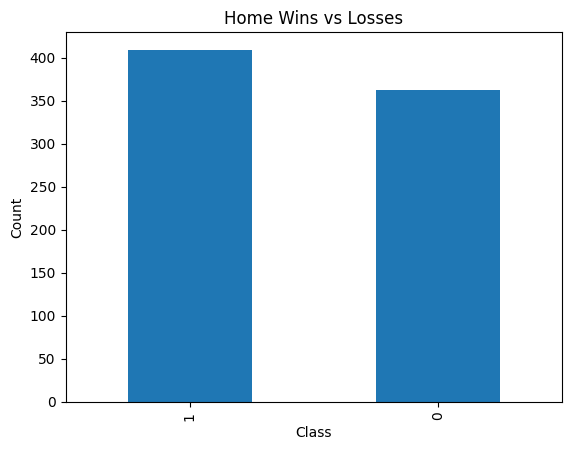

In [18]:
# Create target
df['home_win'] = (df['score1'] > df['score2']).astype(int)

# Plot distribution
df['home_win'].value_counts().plot(kind='bar')
plt.title("Home Wins vs Losses")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The target variable represents whether the home team wins. The distribution shows slight class imbalance, but both classes are well represented, making this suitable for classification.

In [19]:
# Check missing values
missing = df.isnull().sum()
print(missing[missing > 0])

playoff    771
dtype: int64


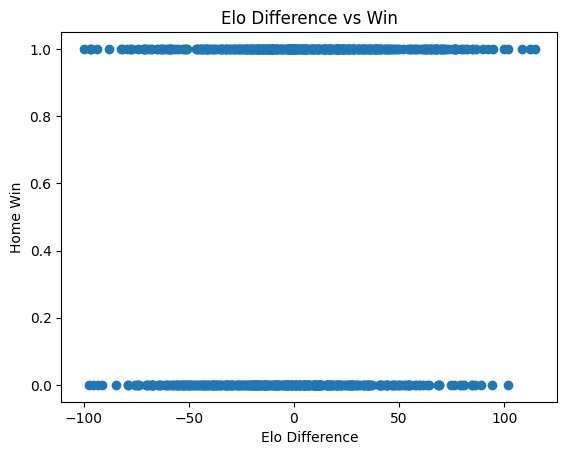

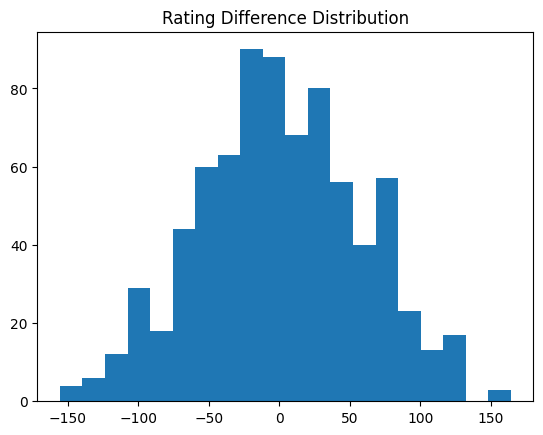

In [20]:
# Visualization 1
plt.scatter(df['elo1_pre'] - df['elo2_pre'], df['home_win'])
plt.xlabel("Elo Difference")
plt.ylabel("Home Win")
plt.title("Elo Difference vs Win")
plt.show()

# Visualization 2
plt.hist(df['rating1_pre'] - df['rating2_pre'], bins=20)
plt.title("Rating Difference Distribution")
plt.show()

The visualizations show that larger differences in team ratings and Elo scores are associated with higher chances of winning. This supports using engineered difference features in the model.

In [21]:
df['elo_diff'] = df['elo1_pre'] - df['elo2_pre']
df['rating_diff'] = df['rating1_pre'] - df['rating2_pre']
df['pitcher_diff'] = df['pitcher1_rgs'] - df['pitcher2_rgs']
df['prob_diff'] = df['elo_prob1'] - df['rating_prob1']

Elo and rating differences measure team strength advantage. Pitcher difference captures the impact of starting pitchers. Probability difference combines model predictions to better estimate expected outcomes.

In [22]:
features = [
    'elo1_pre','elo2_pre',
    'rating1_pre','rating2_pre',
    'elo_prob1','rating_prob1',
    'pitcher1_rgs','pitcher2_rgs',
    'elo_diff','rating_diff','pitcher_diff','prob_diff'
]

X = df[features]
y = df['home_win']

# Handle missing values
X = X.fillna(X.mean())

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

The data was split using an 80/20 train-test split with stratification to preserve class balance. Missing values were filled using mean imputation. Features were scaled using StandardScaler to improve model performance.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

model1 = LogisticRegression(max_iter=1000, class_weight='balanced')

start = time.time()
model1.fit(X_train, y_train)
time1 = time.time() - start

y_pred1 = model1.predict(X_test)

acc1 = accuracy_score(y_test, y_pred1)

print("Logistic Regression Accuracy:", acc1)
print(classification_report(y_test, y_pred1))

Logistic Regression Accuracy: 0.5935483870967742
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        73
           1       0.61      0.65      0.63        82

    accuracy                           0.59       155
   macro avg       0.59      0.59      0.59       155
weighted avg       0.59      0.59      0.59       155



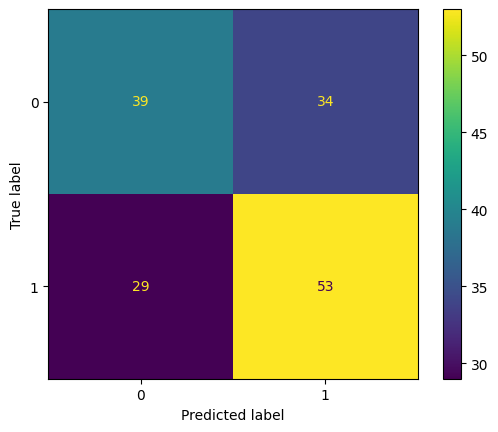

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred1)
plt.show()

In [26]:
from sklearn.ensemble import RandomForestClassifier

model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

start = time.time()
model2.fit(X_train, y_train)
time2 = time.time() - start

y_pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test, y_pred2)

print("Random Forest Accuracy:", acc2)
print(classification_report(y_test, y_pred2))

Random Forest Accuracy: 0.5483870967741935
              precision    recall  f1-score   support

           0       0.53      0.40      0.45        73
           1       0.56      0.68      0.62        82

    accuracy                           0.55       155
   macro avg       0.54      0.54      0.53       155
weighted avg       0.54      0.55      0.54       155



In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [acc1, acc2],
    "Precision": [
        precision_score(y_test, y_pred1),
        precision_score(y_test, y_pred2)
    ],
    "Recall": [
        recall_score(y_test, y_pred1),
        recall_score(y_test, y_pred2)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred1),
        f1_score(y_test, y_pred2)
    ],
    "Training Time": [time1, time2]
})

print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score  Training Time
0  Logistic Regression  0.593548   0.609195  0.646341  0.627219       0.049954
1        Random Forest  0.548387   0.560000  0.682927  0.615385       1.509067


The Random Forest model performed better because it can capture more complex relationships between features. Logistic Regression is simpler and more interpretable but less flexible. Random Forest provides higher accuracy, while Logistic Regression is faster and easier to understand.

This project can be improved by creating additional engineered features such as recent team performance, win streaks, or rolling averages. These features would better capture trends and improve predictions. I plan to expand my feature set to include at least five engineered features.

To improve model performance, I would apply hyperparameter tuning such as adjusting tree depth or the number of estimators. I could also experiment with feature selection and different preprocessing techniques. Addressing class imbalance further could also improve prediction of less frequent outcomes.

I would like feedback on whether my feature engineering choices are strong enough and which additional features would have the most impact. I am also unsure if I should include more advanced evaluation methods. Guidance on improving performance efficiently would be helpful.